# 📊 Crime Analysis Project (DataCamp Practice → Portfolio)

Project Overview

This project was completed as part of a DataCamp practical exercise and adapted into a portfolio-ready analysis.

Objectives:

Identify the hour with the highest frequency of crimes

Identify the area with the highest number of night crimes (22:00–03:59)

Analyse crime frequency by victim age groups

The focus is on clean logic, clear aggregation, and reproducible analysis, not on advanced modelling.

Data Source

This project is based on a practical exercise from **DataCamp**.

The original dataset and task description are available here:  

https://projects.datacamp.com/projects/1876

The data used in this notebook was downloaded directly from DataCamp and analysed locally in Python as part of my learning and portfolio development.

Each row represents one crime.

Time stored in:

TIME OCC → military time format (HHMM)

hour_of_OCC → extracted hour (0–23)

## Download & see data


Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_original = pd.read_csv("C:/MyFiles/Study/Python_Study/Datacamp_crimes.csv")

df= df_original.copy()


In [ ]:
# Initial Data Check

df.head()


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [6]:
df.shape


(185715, 12)

In [7]:
df.columns.tolist()


['DR_NO',
 'Date Rptd',
 'DATE OCC',
 'TIME OCC',
 'AREA NAME',
 'Crm Cd Desc',
 'Vict Age',
 'Vict Sex',
 'Vict Descent',
 'Weapon Desc',
 'Status Desc',
 'LOCATION']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(3), object(9)
memory usage: 17.0+ MB


In [9]:
# Check the missing data

df.isna().sum()

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64

### Improvments (cleaning)


In [10]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
print(df['Date Rptd'].dtypes)

datetime64[ns]


In [11]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
print(df['DATE OCC'].dtypes)

datetime64[ns]


## Question 1: Peak hour

- Which hour has the highest frequency of crimes? Store as an integer variable called peak_crime_hour.

Which hour has the highest frequency of crimes?
Approach

Use the extracted hour column (hour_of_OCC)

Count frequency of crimes per hour

Identify the hour with the maximum count

In [ ]:

df['hour_of_OCC'] = df['TIME OCC']//100
df['hour_of_OCC'].head(10)

0    11
1    16
2    12
3     6
4     9
5    10
6    12
7    13
8     0
9    17
Name: hour_of_OCC, dtype: int64

In [ ]:

crime_hours = df.groupby('hour_of_OCC').size().reset_index()
crime_hours

,hour_of_OCC,0
0,0,8728
1,1,5836
2,2,4726
3,3,3943
4,4,3238
5,5,3171
6,6,5621
7,7,5403
8,8,7523
9,9,7092


In [ ]:


crime_hours.columns = ['hour_of_OCC','count']
crime_hours.head()

,hour_of_OCC,count
0,0,8728
1,1,5836
2,2,4726
3,3,3943
4,4,3238


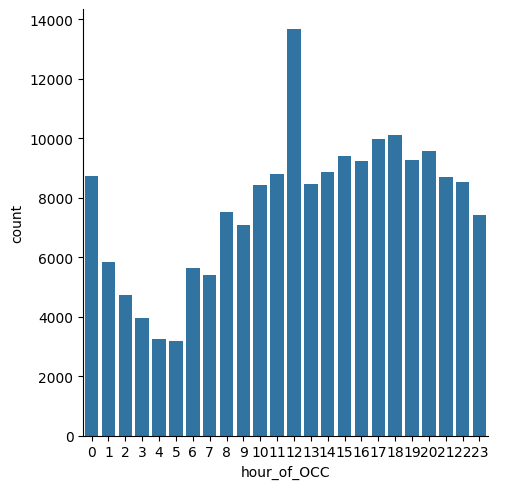

In [ ]:

sns.catplot(x='hour_of_OCC', y='count', data=crime_hours, kind='bar')
plt.show()

In [ ]:

peak_crime_hour = df['hour_of_OCC'].value_counts().idxmax()
peak_crime_hour 


# second possible decision - use sort_values
peak_crime_hour = crime_hours.sort_values('count', ascending=False).iloc[0]['hour_of_OCC']
peak_crime_hour 

np.int64(12)

## Question 2: Peak night-crime area

Which area has the highest frequency of night crimes (22:00–03:59)?

Approach

Filter crimes committed at night:

hour ≥ 22 OR hour < 4

Count crimes by area

Extract the area with the highest frequency

Result must be stored as a string

In [ ]:

night_crimes = df[(df['hour_of_OCC']>=22) | (df['hour_of_OCC']< 4)].reset_index() #this is boolean Now I need to do series

night_crimes['hour_of_OCC'].agg(['min', 'max'])

min     0
max    23
Name: hour_of_OCC, dtype: int64

In [27]:
night_crimes_size = night_crimes['AREA NAME'].value_counts().reset_index()
night_crimes_size

,AREA NAME,count
0,Central,3312
1,Hollywood,2699
2,77th Street,2558
3,Southwest,2347
4,Southeast,2218
5,Newton,2142
6,Olympic,2137
7,Pacific,1916
8,Rampart,1860
9,N Hollywood,1855


In [ ]:

night_crimes_size.columns = ['AREA NAME', 'N_crimes']

night_crimes_size

,AREA NAME,N_crimes
0,Central,3312
1,Hollywood,2699
2,77th Street,2558
3,Southwest,2347
4,Southeast,2218
5,Newton,2142
6,Olympic,2137
7,Pacific,1916
8,Rampart,1860
9,N Hollywood,1855


In [ ]:


idx = night_crimes_size['N_crimes'].idxmax()

peak_night_crime_location  = night_crimes_size.loc[idx, 'AREA NAME'] 

peak_night_crime_location


'Central'

## Question 3: Victim age groups

- Crime frequency by victim age groups

Approach

Work with numeric victim age (Vict Age)

Create age groups using pd.cut()

Count crimes per age group

Identify the most frequent age group

In [ ]:


labels = [
    '0-17',
    '18-25',
    '26-34',
    '35-44',
    '45-54',
    '55-64',
    '65+'
]



In [ ]:


df['age_group'] = pd.cut(df['Vict Age'], bins = [0, 17, 25, 34, 44, 54, 64, 120], labels=labels, right=True)


In [ ]:


df[['Vict Age', 'age_group']].head(20)


,Vict Age,age_group
0,27,26-34
1,60,55-64
2,28,26-34
3,37,35-44
4,79,65+
5,28,26-34
6,33,26-34
7,35,35-44
8,72,65+
9,21,18-25


In [25]:
victim_ages = df['age_group'].value_counts()
victim_ages

age_group
26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
0-17      4528
Name: count, dtype: int64

# 📌 Key Findings

Peak crime hour:  12.00

Area with most night crimes: Central

Most affected age group:  26-34

These results highlight:

Clear temporal concentration of crimes

Specific geographic hotspots during night hours

Distinct age-group patterns in victimisation

Notes for Reproducibility

Analysis uses value_counts() and idxmax() for transparent aggregation

Age groups are explicitly defined, not auto-binned

Night-time logic correctly accounts for crossing midnight

No inplace operations used

Notebook can be rerun top-to-bottom without side effects

Why this works as a portfolio project

✔ Clear problem statements
✔ Clean, readable logic
✔ Correct use of pandas aggregation
✔ Honest scope (no overengineering)
✔ Demonstrates analytical thinking, not just syntax